# Business Objective

* To Build a system to recommend starting pitchers based on predicted fantasy performance to maximize user returns in fantasy sports platforms.

In [1]:
# Core Libs
import numpy as np 
import pandas as pd 

# Visual Libs
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

# ML Libs
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Utility Libs
import shap
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/jabrwocky/2025-mlb-streaming-statistics/mlb_2025_starts_with_streamer_category.csv


# Data Overview

In [2]:
# File Path
path = "/kaggle/input/datasets/jabrwocky/2025-mlb-streaming-statistics/mlb_2025_starts_with_streamer_category.csv"

# Loading Dataset
df = pd.read_csv(path)

In [3]:
# Basic Checks
print("-"* 50)
print("Columns \n", df.columns)
print("-"* 50)
print('shape: ', df.shape)
print("-"* 50)
display(df.info())
print("-"* 50)
display(df.describe())
print("-"* 50)
display(df.head())

--------------------------------------------------
Columns 
 Index(['game_date', 'pitcher_name', 'opponent', 'ballpark', 'fantasy_points',
       'last_start_fp', 'season_avg_fp_prior', 'streamer_category'],
      dtype='object')
--------------------------------------------------
shape:  (3293, 8)
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3293 entries, 0 to 3292
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   game_date            3293 non-null   object 
 1   pitcher_name         3293 non-null   object 
 2   opponent             3293 non-null   object 
 3   ballpark             3293 non-null   object 
 4   fantasy_points       3293 non-null   float64
 5   last_start_fp        3293 non-null   float64
 6   season_avg_fp_prior  3293 non-null   float64
 7   streamer_category    3135 non-null   object 
dtypes: float64(3), object(5)
memory usage: 

None

--------------------------------------------------


,fantasy_points,last_start_fp,season_avg_fp_prior
count,3293.000000,3293.000000,3293.000000
mean,10.810264,11.027118,11.466813
std,11.037187,10.889921,4.975876
min,-27.700000,-26.700000,-19.400000
25%,3.600000,4.000000,8.600000
50%,11.000000,11.300000,11.286667
75%,19.000000,19.000000,14.750000
max,43.000000,43.000000,31.000000


--------------------------------------------------


,game_date,pitcher_name,opponent,ballpark,fantasy_points,last_start_fp,season_avg_fp_prior,streamer_category
0,5/23/2025,Clayton Kershaw,NYM,NYM,6.0,-4.0,-4.000000,Do Not Start
1,5/28/2025,Clayton Kershaw,CLE,CLE,8.0,6.0,1.000000,Do Not Start
2,6/3/2025,Clayton Kershaw,NYM,LAD,-0.4,8.0,3.333333,Do Not Start
3,6/8/2025,Clayton Kershaw,STL,STL,19.0,-0.4,2.400000,Do Not Start
4,6/14/2025,Clayton Kershaw,SFG,LAD,27.0,19.0,5.720000,Questionable Start


In [4]:
# Histogram 
hist = alt.Chart(df).mark_bar(color='#307fc1', opacity=0.8).encode(
    x=alt.X('fantasy_points:Q', bin=alt.Bin(maxbins=30), title='Fantasy Points Scored'),
    y=alt.Y('count():Q', title='Frequency (Number of Starts)')
)

# KDE (Density) Line
kde = alt.Chart(df).transform_density(
    'fantasy_points',
    as_=['fantasy_points', 'density'],
    counts=True 
).mark_line(color='black', strokeWidth=2).encode(
    x='fantasy_points:Q',
    y='density:Q'
)

# Threshold Line
threshold_df = pd.DataFrame({'threshold': [18]})
rule = alt.Chart(threshold_df).mark_rule(
    color='#bf5b3d', 
    strokeDash=[5, 5], 
    strokeWidth=2
).encode(
    x='threshold:Q'
)

label = alt.Chart(threshold_df).mark_text(
    align='left', dx=5, dy=-130, color='#bf5b3d', fontWeight='bold', text='High-Value Threshold (18 pts)'
).encode(
    x='threshold:Q'
)

final_chart = (hist + kde + rule + label).properties(
    width=700,
    height=350,
    title=alt.TitleParams(text='Distribution of Pitcher Fantasy Points', fontSize=16, fontWeight='bold')
).configure_axis(
    grid=True,
    gridOpacity=0.3
)

final_chart

alt.LayerChart(...)

# Data Cleaning & Preprocessing

In [5]:
# Converting Object to Datetime Dtype
df['game_date'] = pd.to_datetime(df['game_date'])

In [6]:
# Data Checkup 
print("-"* 50,'\n Unique Values \n',"-"* 50)
display(df.nunique())
print("-"* 50, '\n Null Values \n',"-"* 50)
display(df.isnull().sum()[df.isnull().sum() > 0])
print("-"* 50, '\n Duplicates \n',"-"* 50)
display(df.duplicated().sum())
print("-"* 50)

-------------------------------------------------- 
 Unique Values 
 --------------------------------------------------


game_date               179
pitcher_name            204
opponent                 30
ballpark                 30
fantasy_points          170
last_start_fp           169
season_avg_fp_prior    2513
streamer_category         4
dtype: int64

-------------------------------------------------- 
 Null Values 
 --------------------------------------------------


streamer_category    158
dtype: int64

-------------------------------------------------- 
 Duplicates 
 --------------------------------------------------


np.int64(0)

--------------------------------------------------


In [7]:
# Filling Nulls with "Unknown"
df['streamer_category'] = df['streamer_category'].fillna("Unknown")

In [8]:
# Sorting rows based on timeline
df = df.sort_values(by='game_date').reset_index(drop=True)

In [9]:
# Rolling mean (last 3 games)
df['rolling_fp_3'] = df.groupby('pitcher_name')['fantasy_points'].shift(1).rolling(3).mean()

# Consistency
df['rolling_std_3'] = df.groupby('pitcher_name')['fantasy_points'].shift(1).rolling(3).std()

# Trend
df['trend'] = df['rolling_fp_3'] - df['season_avg_fp_prior']

In [10]:
# Filling Nulls
df['rolling_fp_3'] = df['rolling_fp_3'].fillna(df['season_avg_fp_prior'])
df['rolling_std_3'] = df['rolling_std_3'].fillna(0)
df['trend'] = df['trend'].fillna(0)

In [11]:
# One Hot Encoding
df = pd.get_dummies(df, columns=['opponent','ballpark'], drop_first=True)

In [12]:
# Training-Testing Split
split_date = df['game_date'].quantile(0.8)

# Add .copy() to create independent dataframes
train = df[df['game_date'] < split_date].copy()
test = df[df['game_date'] >= split_date].copy()

In [13]:
# Feature Selection
features = [
    'last_start_fp',
    'season_avg_fp_prior',
    'rolling_fp_3',
    'rolling_std_3',
    'trend'
] + [col for col in df.columns if 'opponent_' in col or 'ballpark_' in col]

X_train = train[features].fillna(0)
y_train = train['fantasy_points']

X_test = test[features].fillna(0)
y_test = test['fantasy_points']

# Model Training

In [14]:
models = {
    "XGB": XGBRegressor(n_estimators=300,random_state=42),
    "RF": RandomForestRegressor(n_estimators=200,random_state=42)
}

# Run the comparison loop
for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    print(name, "MAE:", np.mean(abs(preds - y_test)))

# winning model
model = models["RF"] 

XGB MAE: 9.960151773374085
RF MAE: 9.044040162627551


In [15]:
test['predicted_fp'] = model.predict(X_test)

ranking = test.sort_values('predicted_fp', ascending=False)
ranking[['pitcher_name','predicted_fp']].head(10)

,pitcher_name,predicted_fp
2954,Freddy Peralta,21.9580
2944,Chris Sale,21.8665
3099,Tarik Skubal,21.8105
2629,Paul Skenes,21.7315
2969,JP Sears,21.5080
2942,Blake Snell,21.5055
3225,Troy Melton,21.3950
3083,Ryan Weathers,21.0115
3222,Carlos Rodon,20.7480
2807,Garrett Crochet,20.0290


In [16]:
def recommend(row):
    if row['predicted_fp'] > 18 and row['rolling_std_3'] < 5:
        return "Safe Pick"
    elif row['predicted_fp'] > 18 and row['trend'] > 0:
        return "In-Form Pick"
    elif row['predicted_fp'] > 15:
        return "Risky Pick"
    else:
        return "Avoid"

test['recommendation'] = test.apply(recommend, axis=1)

In [17]:
top_actual = test.sort_values('fantasy_points', ascending=False).head(10)
top_pred = test.sort_values('predicted_fp', ascending=False).head(10)

accuracy = len(set(top_actual['pitcher_name']) & set(top_pred['pitcher_name']))
print("Top-10 overlap:", accuracy)

top3 = test.sort_values('predicted_fp', ascending=False).head(3)
print("Predicted Picks Score:", top3['fantasy_points'].sum())

random3 = test.sample(3)
print("Random Picks Score:", random3['fantasy_points'].sum())

Top-10 overlap: 1
Predicted Picks Score: 32.0
Random Picks Score: 20.6


In [18]:
def top_k_score(df, k=10):
    actual = df.sort_values('fantasy_points', ascending=False).head(k)
    pred = df.sort_values('predicted_fp', ascending=False).head(k)
    return len(set(actual['pitcher_name']) & set(pred['pitcher_name']))

print("Top-10 Score:", top_k_score(test))

Top-10 Score: 1


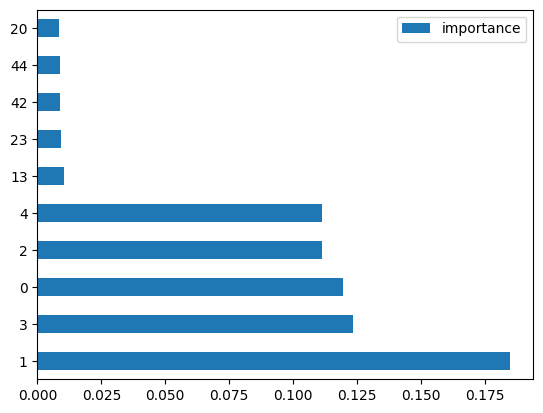

In [19]:
importance = model.feature_importances_
feat_names = X_train.columns

imp_df = pd.DataFrame({'feature': feat_names, 'importance': importance})
imp_df.sort_values(by='importance', ascending=False).head(10).plot(kind='barh')
plt.show()

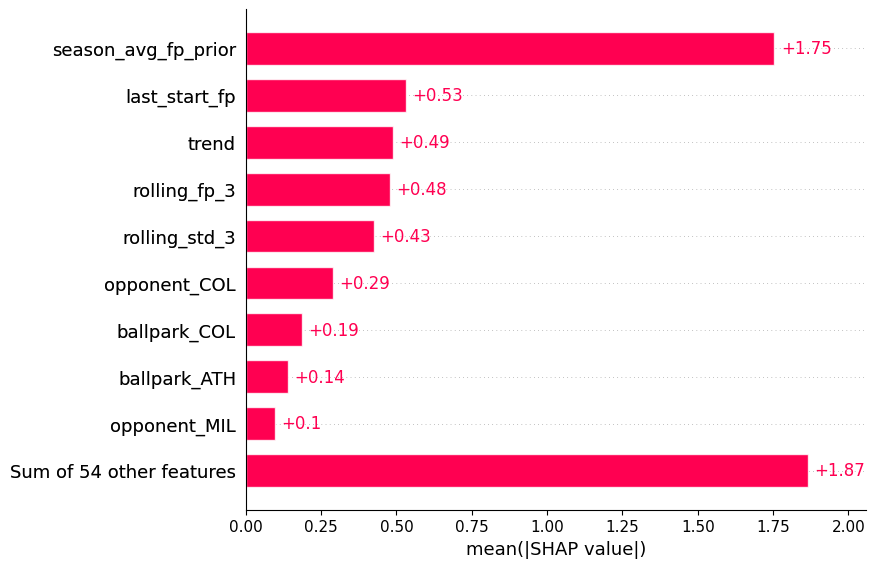

In [20]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

# Conclusion

## Final Insights

- Recent performance (last_start_fp) is strongest predictor  
- Consistency (rolling_std) reduces risk  
- Opponent and venue significantly affect outcomes  

## Business Impact

- Can be used in fantasy sports apps  
- Improves decision-making for users  
- Enables recommendation systems at scale  